# Insurance Premium Prediction

## Overview

 In this project, we will build a regression model to predict recommended insurance policy premiums based on various customer attributes. Our goal is to uncover insights from the data and construct a robust predictive pipeline.

During this process, we will focus on several key areas:

* **Exploratory Data Analysis (EDA) on Mixed-Type Datasets:** We will analyze
datasets containing a blend of numerical and categorical variables to understand their distributions, identify patterns, and spot correlations.

* **Handling Categorical Variables with High Cardinality:** We will implement advanced encoding techniques (such as target encoding or frequency encoding) to manage categorical features that have a massive number of unique values without exploding our feature space.

* **Dealing with Non-Standard Data Entries:** We will clean the dataset by identifying and correcting inconsistent formatting, missing values, and anomalous data entries.

* **Feature Engineering Techniques:** We will create powerful new predictors from raw data to help our models capture complex, non-linear relationships.

* **Building and Evaluating Regression Models:** We will train various machine learning algorithms and rigorously evaluate their performance using metrics like Root Mean Squared Error (RMSE) and R-squared (R
2
 ).

---

## The Dataset

**Target Variable:** `Reco_Policy_Premium` — the recommended premium amount. This is what we are predicting based on inputs.

**Features:**

| Feature | Type | Description |
|---------|------|-------------|
| `Upper_Age` | Numeric | Age of primary policyholder |
| `Lower_Age` | Numeric | Age of secondary person (spouse/dependent) |
| `City_Code` | Categorical | City identifier (C1, C2, ... C36+) |
| `Accomodation_Type` | Categorical | Owned or Rented |
| `Reco_Insurance_Type` | Categorical | Individual or Joint policy |
| `Is_Spouse` | Categorical | Whether spouse is included (Yes/No) |
| `Health Indicator` | Categorical | Health category (X1 through X7) |
| `Holding_Policy_Duration` | Mixed | Years with current policy (numeric, but includes "14+" as string) |
| `Holding_Policy_Type` | Categorical | Policy type (1.0, 2.0, 3.0, 4.0) |

---

## Part 1: Data Loading and Initial Exploration

### Task 1.1: Load the Data

```
load the dataset with name "insurance.csv"
extract the features dataframe and target series
print the shape of the data
```

In [ ]:

# Task 1.1: Load the data
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]



Saving insurance.csv to insurance.csv


### Task 1.2: Initial Inspection

Before jumping into modeling, we need to understand our dataset's structure and health. In this section, we are:
* Previewing the data (first 10 rows)
* Auditing data types and checking for misclassified columns
* Generating summary statistics for numeric distributions
* Measuring cardinality in categorical features
* Auditing missing values across the entire dataset italicized text

In [ ]:

# Task 1.2a: Display first 10 rows
df = pd.read_csv(filename)

X = df.drop(columns=["Reco_Policy_Premium"])
y = df["Reco_Policy_Premium"]

print(f"Dataset shape: {df.shape}")

df.head(10)


Dataset shape: (23548, 11)


,Unnamed: 0,Upper_Age,Lower_Age,Reco_Policy_Premium,City_Code,Accomodation_Type,Reco_Insurance_Type,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type
0,0,52,52,16200.0,C2,Owned,Individual,No,X4,6,4
1,1,67,67,16900.0,C17,Rented,Individual,No,X1,7,3
2,2,75,75,25668.0,C10,Owned,Individual,No,X3,3,1
3,3,60,57,17586.8,C26,Owned,Joint,Yes,X1,14+,1
4,4,35,35,12762.0,C12,Rented,Individual,No,X1,3,2
5,5,75,75,21964.0,C2,Owned,Individual,No,X1,14+,3
6,6,75,75,23744.0,C10,Owned,Individual,No,X3,4,3
7,7,75,70,29083.6,C1,Owned,Joint,Yes,X2,5,1
8,8,51,51,14712.0,C5,Owned,Individual,No,X1,1,3
9,9,33,33,9338.0,C17,Rented,Individual,No,X1,1,1


In [ ]:
# Task 1.2b: Check data types
df.dtypes


,0
Unnamed: 0,int64
Upper_Age,int64
Lower_Age,int64
Reco_Policy_Premium,float64
City_Code,object
Accomodation_Type,object
Reco_Insurance_Type,object
Is_Spouse,object
Health Indicator,object
Holding_Policy_Duration,object


In [ ]:
# Task 1.2c: Summary statistics
df.describe()


,Unnamed: 0,Upper_Age,Lower_Age,Reco_Policy_Premium,Holding_Policy_Type
count,23548.000000,23548.000000,23548.000000,23548.000000,23548.000000
mean,11773.500000,48.864192,46.365381,15409.000161,2.437574
std,6797.866405,16.021466,16.578403,6416.327319,1.025915
min,0.000000,21.000000,16.000000,3216.000000,1.000000
25%,5886.750000,35.000000,32.000000,10704.000000,1.000000
50%,11773.500000,49.000000,46.000000,14580.000000,3.000000
75%,17660.250000,62.000000,60.000000,19140.000000,3.000000
max,23547.000000,75.000000,75.000000,43350.400000,4.000000


In [ ]:
# Task 1.2d: Unique value counts for categorical columns

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Count unique values
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Unique Values: {df[col].nunique()}")
    print(df[col].value_counts())



Column: City_Code
Unique Values: 36
City_Code
C1     4397
C2     3800
C3     2249
C4     1577
C9      932
C7      902
C8      843
C6      831
C10     764
C5      615
C15     576
C17     533
C11     515
C16     456
C20     435
C13     431
C19     407
C12     396
C21     351
C18     351
C14     335
C24     290
C23     244
C22     227
C26     225
C29     168
C25     165
C28     131
C27     116
C33     103
C32      59
C34      51
C30      27
C35      24
C36      15
C31       7
Name: count, dtype: int64

Column: Accomodation_Type
Unique Values: 2
Accomodation_Type
Owned     14457
Rented     9091
Name: count, dtype: int64

Column: Reco_Insurance_Type
Unique Values: 2
Reco_Insurance_Type
Individual    18047
Joint          5501
Name: count, dtype: int64

Column: Is_Spouse
Unique Values: 2
Is_Spouse
No     19063
Yes     4485
Name: count, dtype: int64

Column: Health Indicator
Unique Values: 9
Health Indicator
X1    7682
X2    6252
X3    3912
X4    3638
X5    1141
X6     700
X7     133
X8      

In [ ]:
# Task 1.2e: Check for missing values
df.isnull().sum()


,0
Unnamed: 0,0
Upper_Age,0
Lower_Age,0
Reco_Policy_Premium,0
City_Code,0
Accomodation_Type,0
Reco_Insurance_Type,0
Is_Spouse,0
Health Indicator,0
Holding_Policy_Duration,0


---

## Part 2: Exploratory Data Analysis

### Task 2.1: Target Variable Analysis

In this step, we focus entirely on understanding our target feature, `Reco_Policy_Premium`. We will plot a histogram to check its distribution shape, calculate its mathematical skewness, and use a boxplot to identify any outliers that could skew our regression model. Finally, we will extract key mathematical markers—including the minimum, maximum, median, and quartiles—to guide our upcoming feature engineering and modeling strategies.

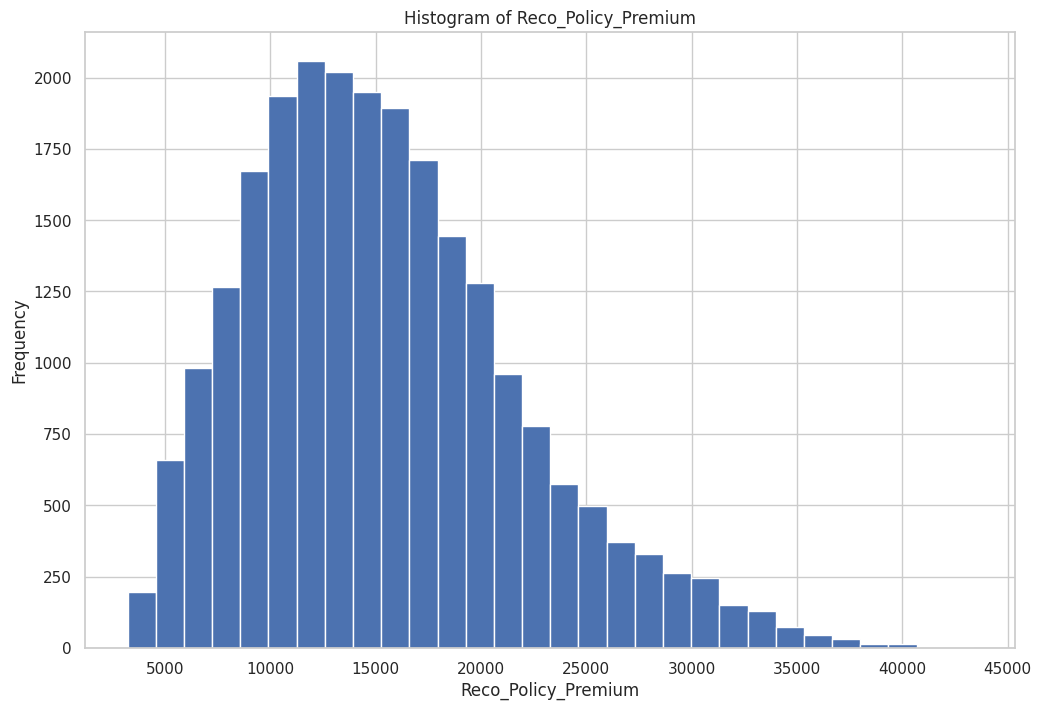

In [ ]:

# Task 2.1a: Histogram of target variable

plt.figure()
plt.hist(df["Reco_Policy_Premium"], bins=30)
plt.title("Histogram of Reco_Policy_Premium")
plt.xlabel("Reco_Policy_Premium")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Task 2.1b: Calculate skewness

skewness = df["Reco_Policy_Premium"].skew()
print("Skewness of Reco_Policy_Premium:", skewness)



Skewness of Reco_Policy_Premium: 0.7241164198074089


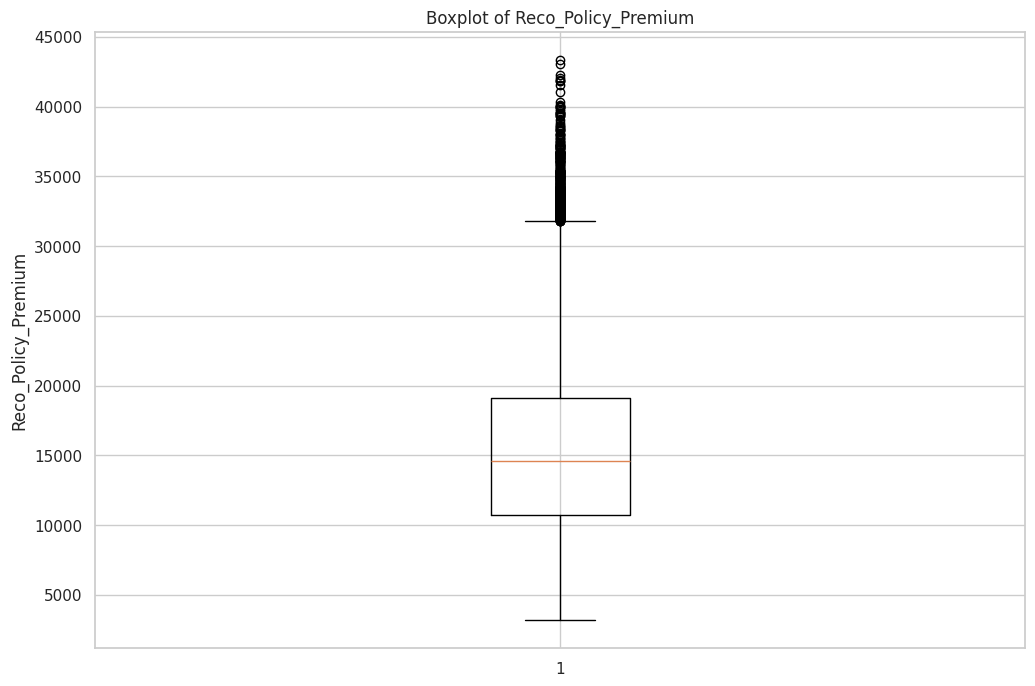

In [ ]:

# Task 2.1c: Boxplot for outliers

plt.figure()
plt.boxplot(df["Reco_Policy_Premium"])
plt.title("Boxplot of Reco_Policy_Premium")
plt.ylabel("Reco_Policy_Premium")
plt.show()



In [ ]:

# Task 2.1d: Summary statistics of target

print("Minimum:", df["Reco_Policy_Premium"].min())
print("Q1 (25%):", df["Reco_Policy_Premium"].quantile(0.25))
print("Median (50%):", df["Reco_Policy_Premium"].median())
print("Q3 (75%):", df["Reco_Policy_Premium"].quantile(0.75))
print("Maximum:", df["Reco_Policy_Premium"].max())



Minimum: 3216.0
Q1 (25%): 10704.0
Median (50%): 14580.0
Q3 (75%): 19140.0
Maximum: 43350.4


### Task 2.2: Feature Relationships

In this step, we investigate how our independent variables relate to `Reco_Policy_Premium`. We will compute a numeric correlation matrix and visualize it with a heatmap to uncover direct associations. For our categorical data, we will map out distributions and calculate group means using boxplots to see which categories drive premiums up or down. Finally, we will use scatter plots to isolate and inspect the specific effects that customer age limits (`Upper_Age` and `Lower_Age`) have on the recommended premium.

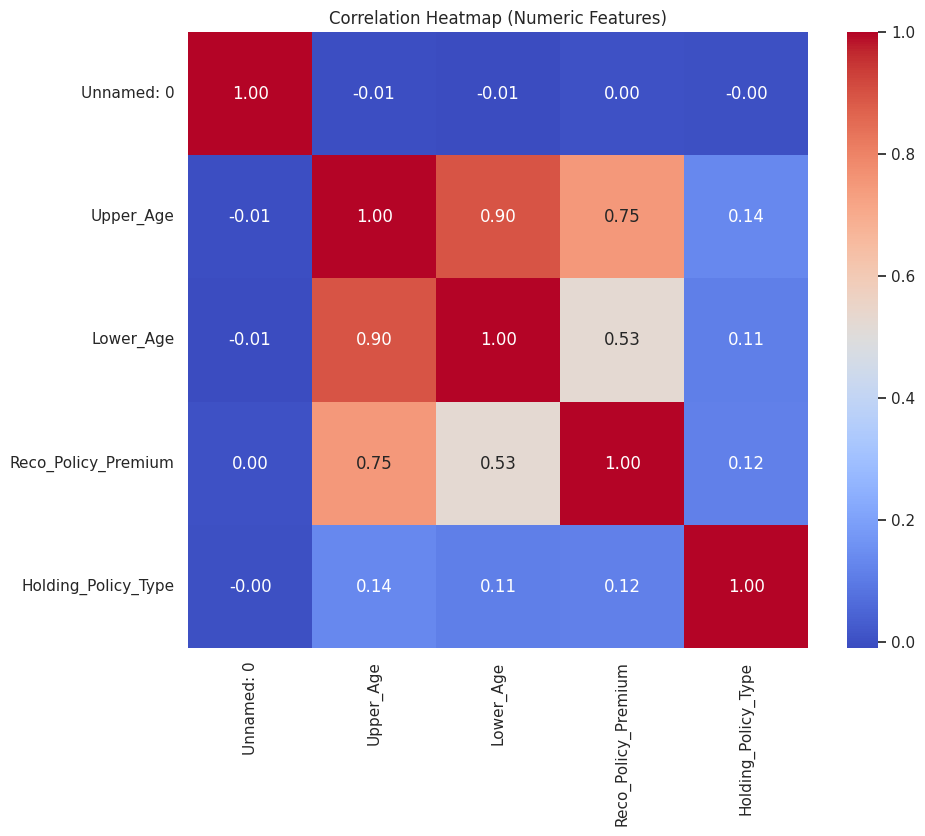

In [ ]:
# Task 2.2a: Correlation matrix and heatmap

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Select numeric columns (including target)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


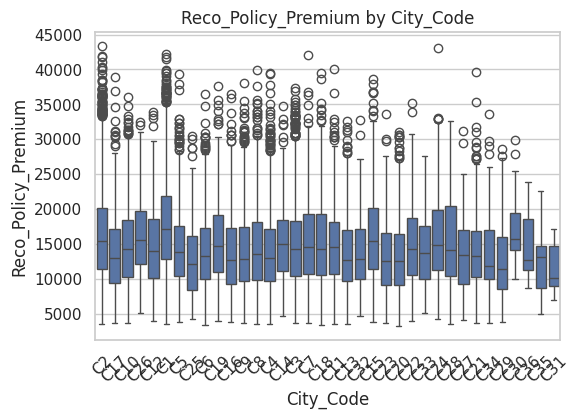


Mean Reco_Policy_Premium by City_Code:
City_Code
C1     17830.288606
C10    14750.774607
C11    15021.027961
C12    14681.832828
C13    13720.791647
C14    15190.229851
C15    16140.398958
C16    13896.156579
C17    13752.521576
C18    15409.528205
C19    15421.784275
C2     16230.840053
C20    13341.863908
C21    14114.900855
C22    15060.570044
C23    13125.728689
C24    15872.314483
C25    12730.575758
C26    15879.354667
C27    13836.575862
C28    15513.520611
C29    12374.332143
C3     14880.642686
C30    17355.570370
C31    11632.857143
C32    13990.169492
C33    14121.924272
C34    14212.325490
C35    12371.433333
C36    14954.853333
C4     13863.199873
C5     14521.622439
C6     13874.994465
C7     15328.168958
C8     14537.642942
C9     13931.567597
Name: Reco_Policy_Premium, dtype: float64


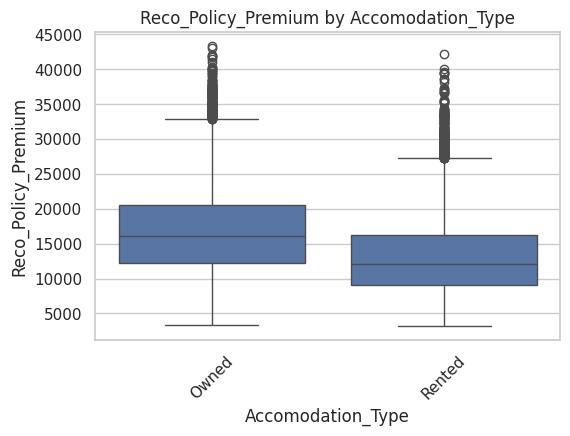


Mean Reco_Policy_Premium by Accomodation_Type:
Accomodation_Type
Owned     16843.586622
Rented    13127.643164
Name: Reco_Policy_Premium, dtype: float64


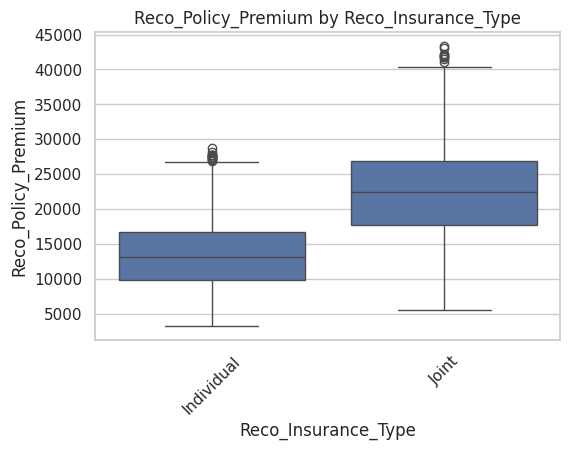


Mean Reco_Policy_Premium by Reco_Insurance_Type:
Reco_Insurance_Type
Individual    13298.605198
Joint         22332.522778
Name: Reco_Policy_Premium, dtype: float64


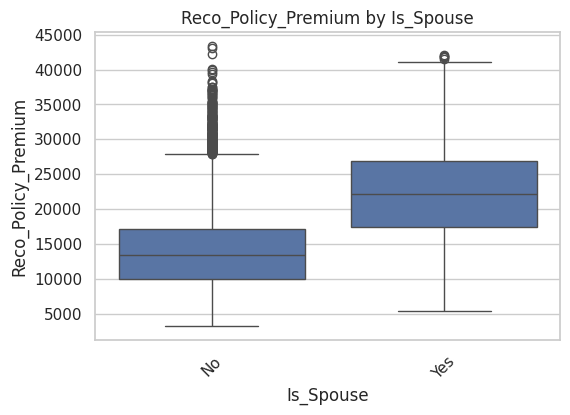


Mean Reco_Policy_Premium by Is_Spouse:
Is_Spouse
No     13821.166626
Yes    22157.912241
Name: Reco_Policy_Premium, dtype: float64


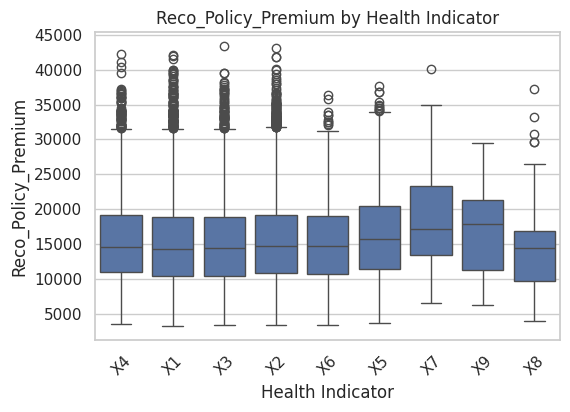


Mean Reco_Policy_Premium by Health Indicator:
Health Indicator
X1    15143.834340
X2    15617.143218
X3    15043.182566
X4    15539.206322
X5    16584.891148
X6    15255.314000
X7    18546.627068
X8    15360.488889
X9    16639.161111
Name: Reco_Policy_Premium, dtype: float64


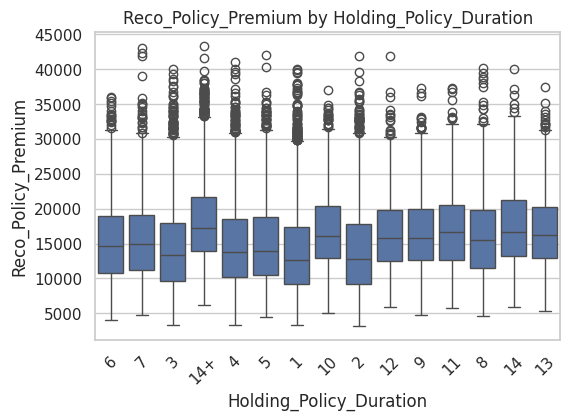


Mean Reco_Policy_Premium by Holding_Policy_Duration:
Holding_Policy_Duration
1      13741.463972
10     17138.324272
11     17169.938208
12     16794.741969
13     17109.555721
14     17765.342541
14+    18351.373999
2      13943.708709
3      14310.046154
4      14856.610309
5      15069.863129
6      15236.872355
7      15622.603279
8      16095.900497
9      16670.143091
Name: Reco_Policy_Premium, dtype: float64


In [ ]:
# Task 2.2b: Boxplots of premium by categorical features
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], y=df["Reco_Policy_Premium"])
    plt.title(f"Reco_Policy_Premium by {col}")
    plt.xticks(rotation=45)
    plt.show()

    # Mean premium per category
    print(f"\nMean Reco_Policy_Premium by {col}:")
    print(df.groupby(col)["Reco_Policy_Premium"].mean())



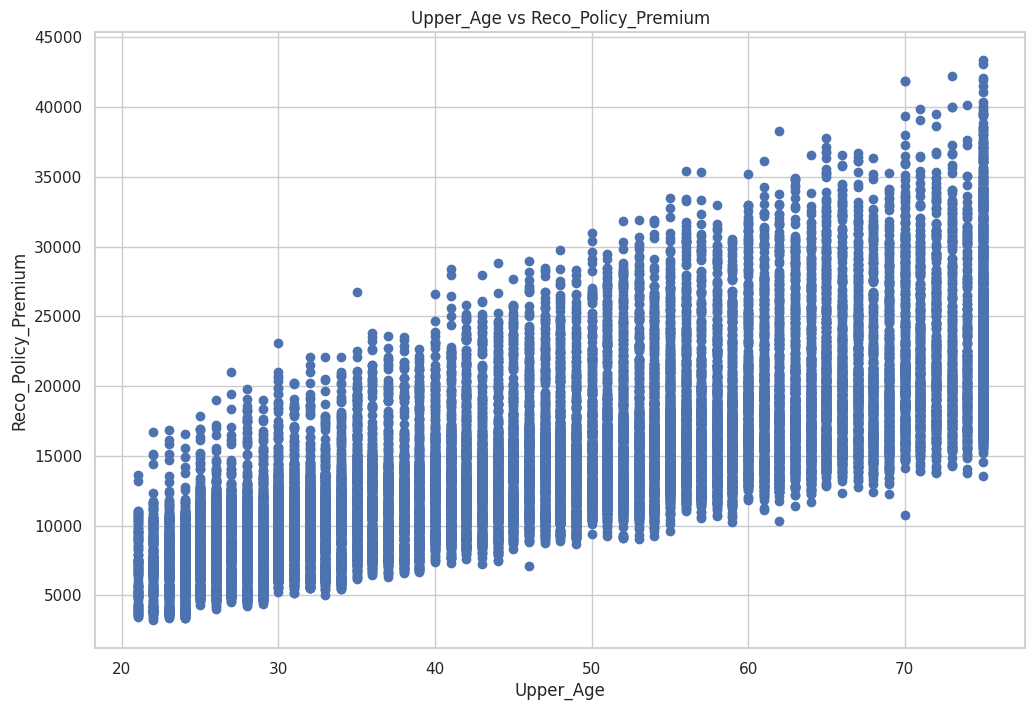

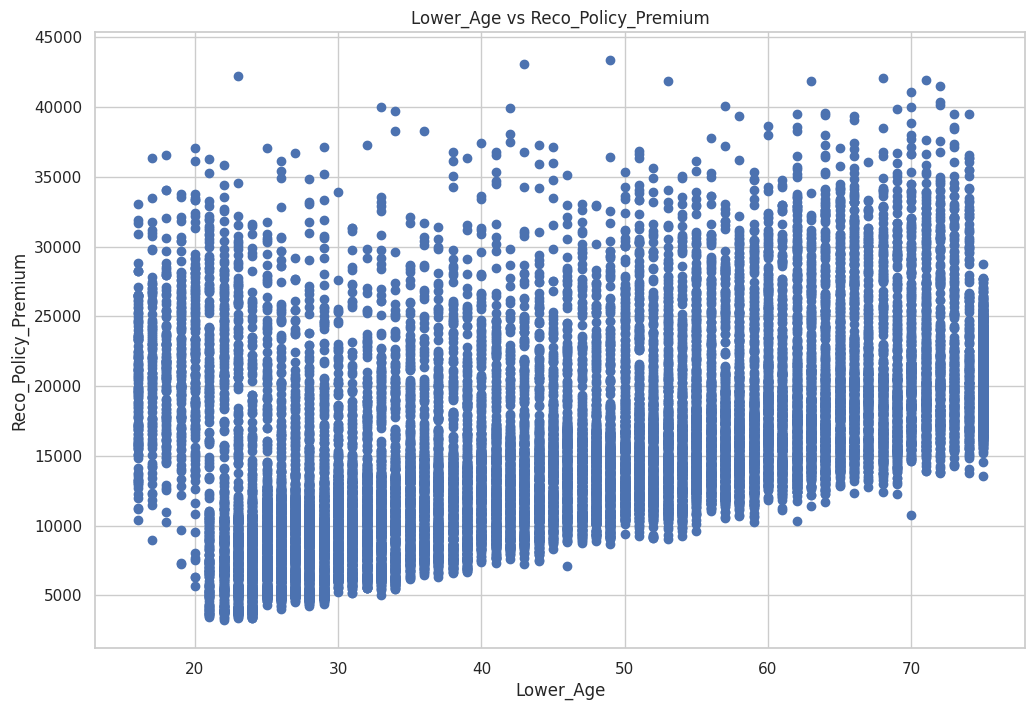

In [ ]:
# Task 2.2c: Scatter plots - Age vs Premium
# Scatter plot: Upper_Age vs Premium
plt.figure()
plt.scatter(df["Upper_Age"], df["Reco_Policy_Premium"])
plt.xlabel("Upper_Age")
plt.ylabel("Reco_Policy_Premium")
plt.title("Upper_Age vs Reco_Policy_Premium")
plt.show()

# Scatter plot: Lower_Age vs Premium
plt.figure()
plt.scatter(df["Lower_Age"], df["Reco_Policy_Premium"])
plt.xlabel("Lower_Age")
plt.ylabel("Reco_Policy_Premium")
plt.title("Lower_Age vs Reco_Policy_Premium")
plt.show()



### Task 2.3: Investigating the Problematic Column

The `Holding_Policy_Duration` column contains a data quality issue.

* printing unique values in Holding_Policy_Duration column
* counting how many rows contain "14+"
* checking the data type of this column

In [ ]:

# Task 2.3: Investigate Holding_Policy_Duration

# 1️⃣ Print unique values
print("Unique values in Holding_Policy_Duration:")
print(df["Holding_Policy_Duration"].unique())

# 2️⃣ Count how many rows contain "14+"
count_14_plus = (df["Holding_Policy_Duration"] == "14+").sum()
print("\nNumber of rows containing '14+':", count_14_plus)

# 3️⃣ Check data type
print("\nData type of Holding_Policy_Duration:")
print(df["Holding_Policy_Duration"].dtype)



Unique values in Holding_Policy_Duration:
['6' '7' '3' '14+' '4' '5' '1' '10' '2' '12' '9' '11' '8' '14' '13']

Number of rows containing '14+': 3323

Data type of Holding_Policy_Duration:
object


---

## Part 3: Data Preprocessing

### Task 3.1: Handling the "14+" Problem

In this step, we are addressing the non-standard `"14+"` entries in `Holding_Policy_Duration`. We have opted for a hybrid approach : first, we extract the unique signal of long-term policy holders by creating a binary column (`is_long_term_holder`). Next, we replace the `"14+"` string with a clean numeric value of `14` in the original column and convert the entire feature to a numeric data type, ensuring we don't lose information or disrupt the mathematical continuity of the data.

In [ ]:
# Task 3.1: Handle the "14+" problem
# OPTION C

# Replace "14+" with 14 first
df["Holding_Policy_Duration"] = df["Holding_Policy_Duration"].replace("14+", 14)

# Convert to numeric
df["Holding_Policy_Duration"] = pd.to_numeric(df["Holding_Policy_Duration"])

# Create bins
df["Duration_Category"] = pd.cut(
    df["Holding_Policy_Duration"],
    bins=[0, 5, 10, 14],
    labels=["Short", "Medium", "Long"]
)

# Convert to category type
df["Duration_Category"] = df["Duration_Category"].astype("category")

# Verify
print(df[["Holding_Policy_Duration", "Duration_Category"]].head())



   Holding_Policy_Duration Duration_Category
0                        6            Medium
1                        7            Medium
2                        3             Short
3                       14              Long
4                        3             Short


### Task 3.2: Encoding Categorical Variables


In this step, we are transforming our categorical variables into numerical values using a diversified encoding strategy. We will use clean binary mapping for standard two-state flags. For structured features like `Health Indicator` and `Holding_Policy_Type`, we will evaluate whether they possess an inherent mathematical order before choosing our encoder. Finally, to handle the high-cardinality `City_Code` column without causing a feature explosion, we have to apply Frequency Encoding based on how often each city appears in our dataset.

In [ ]:
# Task 3.2a: Encode binary categorical variables

binary_cols = ["Accomodation_Type", "Is_Spouse", "Reco_Insurance_Type"]

for col in binary_cols:
    print(f"\nUnique values in {col}:", df[col].unique())

# Example binary mapping (adjust if needed based on your dataset values)

df["Accomodation_Type"] = df["Accomodation_Type"].map({
    "Owned": 1,
    "Rented": 0
})

df["Is_Spouse"] = df["Is_Spouse"].map({
    "Yes": 1,
    "No": 0
})

df["Reco_Insurance_Type"] = df["Reco_Insurance_Type"].map({
    "Individual": 0,
    "Joint": 1
})

print(df[binary_cols].head())



Unique values in Accomodation_Type: ['Owned' 'Rented']

Unique values in Is_Spouse: ['No' 'Yes']

Unique values in Reco_Insurance_Type: ['Individual' 'Joint']
   Accomodation_Type  Is_Spouse  Reco_Insurance_Type
0                  1          0                    0
1                  0          0                    0
2                  1          0                    0
3                  1          1                    1
4                  0          0                    0


In [ ]:
# Task 3.2b: Encode Health Indicator

df["Health Indicator"] = df["Health Indicator"].str.replace("X", "")
df["Health Indicator"] = pd.to_numeric(df["Health Indicator"])

print(df["Health Indicator"].head())



0    4
1    1
2    3
3    1
4    1
Name: Health Indicator, dtype: int64


In [ ]:
# Task 3.2c: Encode City_Code (high cardinality)
# Task 3.2c: Frequency Encoding for City_Code

city_freq = df["City_Code"].value_counts(normalize=True)

df["City_Code_FE"] = df["City_Code"].map(city_freq)

print(df[["City_Code", "City_Code_FE"]].head())

# Drop original column if needed
df.drop("City_Code", axis=1, inplace=True)



  City_Code  City_Code_FE
0        C2      0.161373
1       C17      0.022635
2       C10      0.032444
3       C26      0.009555
4       C12      0.016817


In [ ]:
# Task 3.2d: Encode Holding_Policy_Type
print(df["Holding_Policy_Type"].unique())



[4 3 1 2]


### Task 3.3: Feature Engineering
In this step, we transform raw variables into powerful engineered features to boost our model's performance. We will calculate an `age_gap` metric and a binary `is_joint_policy` flag to properly contextualize multi-person plans. To capture non-linear age effects, we will discretize customer ages into distinct behavioral `age_groups`. Finally, we will construct interaction terms—combining age with health indicators and policy types—allowing our linear or tree-based algorithms to easily learn complex, overlapping risk relationships.

In [ ]:

# 1️⃣ Age Gap Feature
df["age_gap"] = df["Upper_Age"] - df["Lower_Age"]

# 2️⃣ is_joint_policy Feature

# If Reco_Insurance_Type still text:
if df["Reco_Insurance_Type"].dtype == "object":
    df["is_joint_policy"] = np.where(df["Reco_Insurance_Type"] == "Joint", 1, 0)
else:
    # If already encoded (0/1)
    df["is_joint_policy"] = df["Reco_Insurance_Type"]

# 3️⃣ Age Group Feature (Binning)

df["age_group"] = pd.cut(
    df["Upper_Age"],
    bins=[0, 30, 50, 65, 120],
    labels=["young", "middle", "senior", "elderly"]
)

# Convert to category
df["age_group"] = df["age_group"].astype("category")

# Optional: One-hot encode age_group for modeling
df = pd.get_dummies(df, columns=["age_group"], drop_first=True)

# 4️⃣ Interaction Features


# Ensure Health Indicator is numeric
if df["Health Indicator"].dtype == "object":
    df["Health Indicator"] = df["Health Indicator"].str.replace("X", "")
    df["Health Indicator"] = pd.to_numeric(df["Health Indicator"])

# age × health interaction
df["age_x_health"] = df["Upper_Age"] * df["Health Indicator"]

# joint × age gap interaction
df["joint_x_age_gap"] = df["is_joint_policy"] * df["age_gap"]

# Preview engineered features
print(df[[
    "age_gap",
    "is_joint_policy",
    "age_x_health",
    "joint_x_age_gap"
]].head())


   age_gap  is_joint_policy  age_x_health  joint_x_age_gap
0        0                0           208                0
1        0                0            67                0
2        0                0           225                0
3        3                1            60                3
4        0                0            35                0


---

## Part 4: Model Building

### Task 4.1: Preparing Train/Test Split

* separating features (X) from target (y)
* splitting data: 80% training, 20% testing
* setting a random_state for reproducibility

In [ ]:
# Task 4.1: Train/Test Split
from sklearn.model_selection import train_test_split

# 1️⃣ Separate features and target

X = df.drop("Reco_Policy_Premium", axis=1)
y = df["Reco_Policy_Premium"]

# 2️⃣ Train-Test Split (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 3️⃣ Verify Shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



X_train shape: (18838, 18)
X_test shape: (4710, 18)
y_train shape: (18838,)
y_test shape: (4710,)


### Task 4.2: Creating a Preprocessing Pipeline

In this step, we automate our data cleaning and transformations by wrapping them inside an unified preprocessing pipeline. We will separate our data into numeric and categorical paths: the numeric branch will handle median imputation and standard scaling, while the categorical branch will manage mode imputation and one-hot encoding. By bundling these paths into a centralized `ColumnTransformer` and combining it with our regression models, we eliminate data leakage, ensure consistent transformations on test data, and build a production-ready codebase.

In [ ]:
# Task 4.2: Create preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
import numpy as np

# 1️⃣ Separate X and y

X = df.drop("Reco_Policy_Premium", axis=1)
y = df["Reco_Policy_Premium"]

# 2️⃣ Identify Numeric and Categorical Features

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

# 3️⃣ Numeric Transformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 4️⃣ Categorical Transformer

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# 5️⃣ Column Transformer

column_transformer = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 6️⃣ Full Pipeline

full_pipeline = Pipeline(steps=[
    ("preprocessor", column_transformer),
    ("model", LinearRegression())
])

print("Pipeline successfully created!")



Numeric Features: ['Unnamed: 0', 'Upper_Age', 'Lower_Age', 'Accomodation_Type', 'Reco_Insurance_Type', 'Is_Spouse', 'Health Indicator', 'Holding_Policy_Duration', 'Holding_Policy_Type', 'City_Code_FE', 'age_gap', 'is_joint_policy', 'age_x_health', 'joint_x_age_gap']
Categorical Features: ['Duration_Category']
Pipeline successfully created!


### Task 4.3: Training Baseline Model

In this step, we establish our project's performance baseline by integrating a standard Linear Regression model into our pipeline. We will fit this setup on our training data and generate predictions on the test set. To objectively evaluate this initial model, we will calculate its $R^2$ score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). These metrics will serve as our essential benchmark, allowing us to quantify exactly how much value more advanced machine learning models add in subsequent steps.

In [ ]:
# Task 4.3: Train baseline model (Linear Regression)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================
# 1. Define Features & Target
# =========================

# CHANGE 'target' to your actual target column name
target_column = "target"

X = df.drop(columns=[target_column])
y = df[target_column]

# =========================
# 2. Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. Preprocessing
# =========================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

column_transformer = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# =========================
# 4. Create Pipeline
# =========================

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", column_transformer),
    ("model", LinearRegression())
])

# =========================
# 5. Fit Model
# =========================

baseline_pipeline.fit(X_train, y_train)

# =========================
# 6. Predict
# =========================

y_pred = baseline_pipeline.predict(X_test)

# =========================
# 7. Evaluation Metrics
# =========================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression Performance:")
print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


Baseline Linear Regression Performance:
R² Score: 0.7944000500842008
MAE: 2347.236305844029
RMSE: 2924.739120008831


**Record your baseline results:**

### Task 4.4: Multi-Model Benchmarking & Cross-Validation

In this step, we scale up our modeling efforts by testing alternative algorithms against our baseline. We will pipeline and evaluate Ridge Regression, Random Forest, and Gradient Boosting estimators. To ensure our results are reliable and protect against overfitting, we will subject each pipeline to 5-fold cross-validation. We will track the stability of our $R^2$ scores (mean and standard deviation) and average MAE across all folds, ultimately organizing the results into a centralized summary table to crown our best-performing architecture.

In [ ]:
# Task 4.4: Try alternative models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate
import pandas as pd

# Define Models

models_to_try = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

# Cross-Validation

results = []

for name, model in models_to_try.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", column_transformer),
        ("model", model)
    ])

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=("r2", "neg_mean_absolute_error"),
        return_train_score=False
    )

    mean_r2 = cv_results["test_r2"].mean()
    std_r2 = cv_results["test_r2"].std()
    mean_mae = -cv_results["test_neg_mean_absolute_error"].mean()

    results.append([name, mean_r2, std_r2, mean_mae])

# Summary Table

results_df = pd.DataFrame(
    results,
    columns=["Model", "Mean R²", "Std R²", "Mean MAE"]
)

print("\nModel Comparison (5-Fold Cross Validation):")
print(results_df.sort_values(by="Mean R²", ascending=False))




Model Comparison (5-Fold Cross Validation):
               Model   Mean R²    Std R²     Mean MAE
3  Gradient Boosting  0.816008  0.006073  2251.927495
1   Ridge Regression  0.798724  0.006387  2324.658495
0  Linear Regression  0.798723  0.006388  2324.663829
2      Random Forest  0.797834  0.007165  2334.705469


## Task 5.1: Residual Diagnostics & Error Analysis
Before trusting our top-performing model, we must audit its errors to ensure it isn't systematically mispricing certain types of policies. In this section, we are:
* Isolating model errors: We will generate predictions on our test set using our best model and compute the residuals ($Actual - Predicted$).
* Testing for homoscedasticity: We will plot residuals against predicted values to check for a random scatter, ensuring our error variance remains constant across all premium levels.
* Checking error normality: We will build a histogram of our residuals to verify they form a clean, normal distribution centered around zero.
* Hunting for missed relationships: We will plot residuals against key features (like age or health status) to ensure our model has fully extracted all available predictive signals and left no patterns behind.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
best_model = Pipeline(steps=[
    ("preprocessor", column_transformer),
    ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))
])
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

residuals = y_test - y_pred

print("Predictions head:", y_pred[:5])
print("Residuals head:", residuals.head())


Predictions head: [13919.45197639 29096.0993782  15901.40455336 14129.29649154
 11286.9681211 ]
Residuals head: 15340    4410.548024
8406    -4047.299378
11106    2270.595447
11854     342.703508
3501     3079.031879
Name: Reco_Policy_Premium, dtype: float64


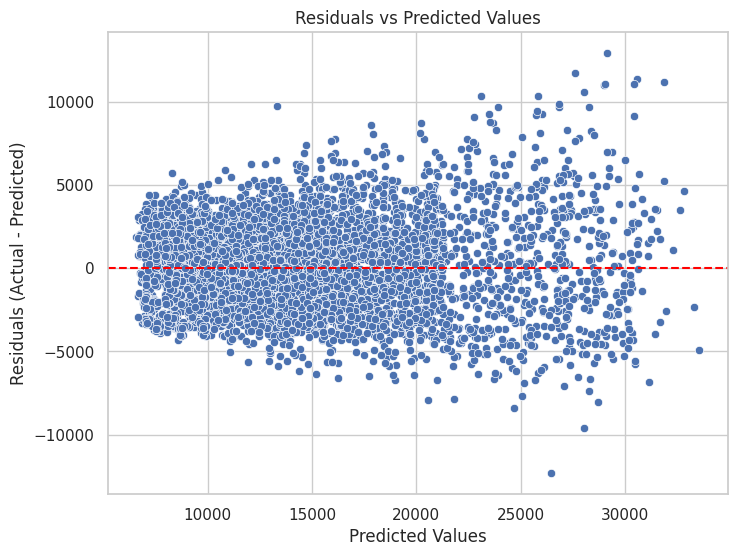

In [ ]:
# Task 5.1b: Plot residuals vs predicted values

import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.show()



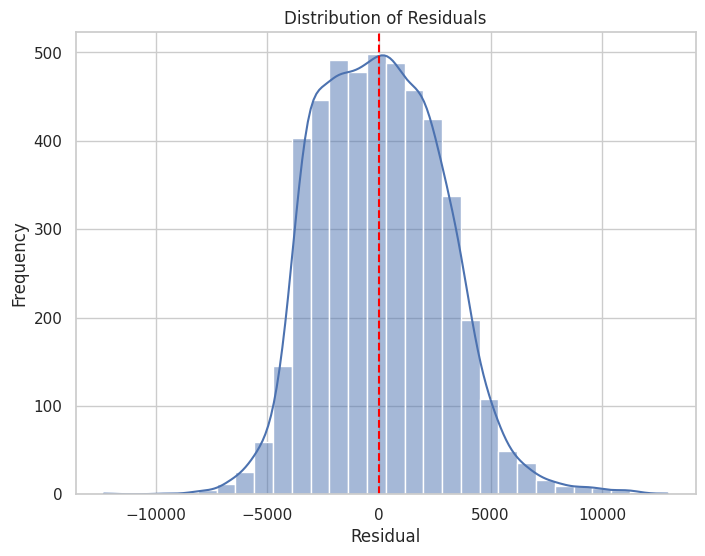

In [ ]:
# Task 5.1c: Histogram of residuals
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


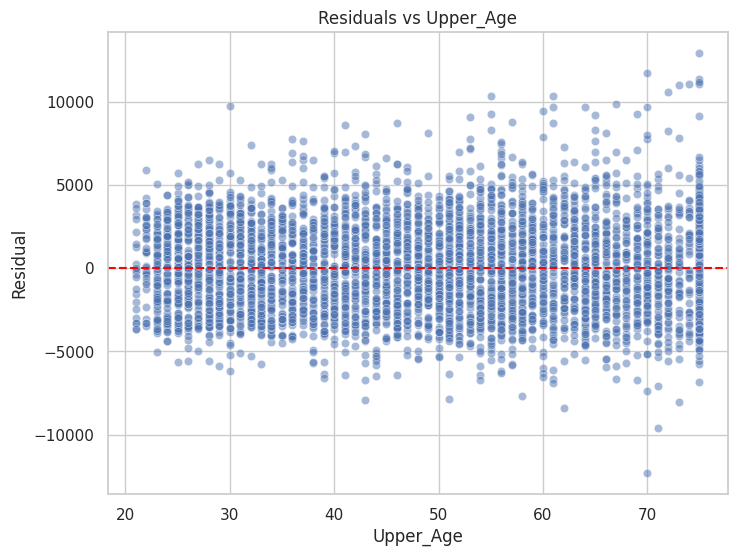

Feature 'vehicle_value' not found in X_test columns.
Feature 'annual_mileage' not found in X_test columns.


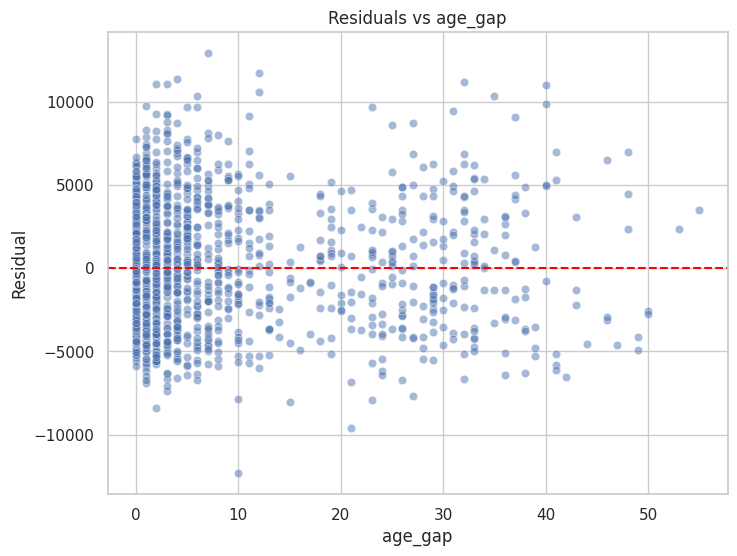

In [ ]:
# Task 5.1d: Residuals vs features
import matplotlib.pyplot as plt
import seaborn as sns

# List of important features (use actual column names in X_test)
important_features = ['Upper_Age', 'vehicle_value', 'annual_mileage', 'age_gap']  # adjust as needed

# Add residuals to X_test for plotting
X_test_with_residuals = X_test.copy()
X_test_with_residuals['Residual'] = residuals

# Plot residuals vs each important feature
for feature in important_features:
    if feature in X_test_with_residuals.columns:
        plt.figure(figsize=(8,6))
        sns.scatterplot(
            x=X_test_with_residuals[feature],
            y=X_test_with_residuals['Residual'],
            alpha=0.5
        )
        plt.axhline(0, color='red', linestyle='--')
        plt.xlabel(feature)
        plt.ylabel("Residual")
        plt.title(f"Residuals vs {feature}")
        plt.show()
    else:
        print(f"Feature '{feature}' not found in X_test columns.")




### Task 5.2: Hyperparameter Tuning


Now that we have selected our champion algorithm, we want to squeeze out maximum performance by fine-tuning its internal structural settings. In this section, we are:
* Defining the search space: We will construct a targeted parameter grid based on our best model—adjusting trees, depths, and splits for **Random Forest**, or estimators and learning rates for **Gradient Boosting**.
* Executing a systemic search: We will run a cross-validated Grid Search (`GridSearchCV`) to exhaustively test every combination of these settings under strict evaluation.
* Isolating the optimal configuration: We will extract and print the exact mathematical parameters that yielded the highest cross-validation score.
* Finalizing performance: We will rebuild our final model using these optimized settings and evaluate its ultimate predictive power on our unseen test dataset.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

full_pipeline.set_params(
    model=GradientBoostingRegressor(random_state=42)
)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Unnamed: 0', 'Upper_Age',
                                                   'Lower_Age',
                                                   'Accomodation_Type',
                                                   'Reco_Insurance_Type',
                                                   'Is_Spouse',
                                                   'Health Indicator',
                                                   'Holding_Policy_Duration',
                                                   'Holding_Policy_Type',
                                                   'City_Code_FE', 'age_gap',
                                                   'is_joint_policy',
                                                   'age_x_health',
                                                   'joint_x_age_gap']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Duration_Category'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Reduced but meaningful parameter grid
gb_param_grid = {
    "model__n_estimators": [100, 200],      # model capacity
    "model__learning_rate": [0.05, 0.1],    # learning control
    "model__max_depth": [3, 5]              # tree complexity
}

# Grid Search with balanced CV
gb_grid = GridSearchCV(
    full_pipeline,     # REUSE existing pipeline
    gb_param_grid,
    cv=3,              # balanced (not too slow, not too weak)
    scoring="r2",
    n_jobs=-1
)

# Fit
gb_grid.fit(X_train, y_train)

# Best parameters and CV score
print("Best Parameters:", gb_grid.best_params_)
print("Best CV R² Score:", gb_grid.best_score_)

# Test set evaluation
y_pred = gb_grid.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV R² Score: 0.8159213999354336
Test R²: 0.8134986328383181
Test MAE: 2265.1504765941254
Test RMSE: 2785.5864530605404


### Task 5.3: Feature Importance

An accurate model is only valuable if we can trust and understand how it makes decisions. In this final evaluation step, we are uncovering the core drivers behind our insurance premium predictions:
* Extracting tree-based weights: If our champion model is an ensemble tree, we will pull its native feature importance values and map them directly back to our engineered column names.
* Implementing model-agnostic alternatives: To ensure a robust analysis, we can alternatively calculate Permutation Importance on our test set, which measures how much our error drops when a specific feature's data is scrambled.
* Ranking key metrics: We will sort our features in descending order to isolate the heavy hitters that impact pricing the most.
* Visualizing the insights: We will generate a horizontal bar chart displaying the top 15 features, giving stakeholders a transparent, visual look at what variables truly drive premium costs.

Model does not support built-in feature importances.
Using permutation importance instead...


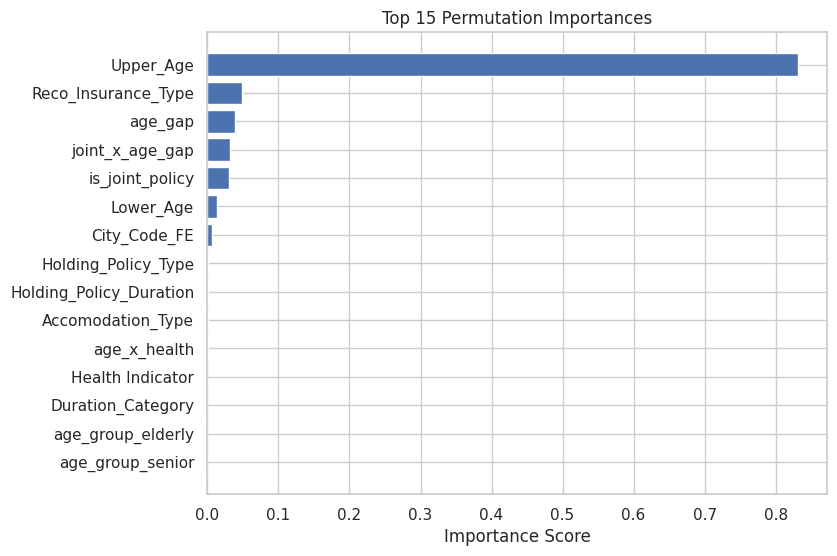

,Feature,Importance
1,Upper_Age,0.831407
4,Reco_Insurance_Type,0.048998
11,age_gap,0.039392
17,joint_x_age_gap,0.032141
12,is_joint_policy,0.030978
2,Lower_Age,0.012806
10,City_Code_FE,0.006868
8,Holding_Policy_Type,0.001108
7,Holding_Policy_Duration,0.000506
3,Accomodation_Type,0.000491


In [ ]:
# Task 5.3: Feature importance analysis (error-safe)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

# Step 1: Choose available trained model
if 'best_tuned_model' in globals():
    model_to_use = best_tuned_model
elif 'best_model' in globals():
    model_to_use = best_model
else:
    raise ValueError("No trained model found. Run model training first.")

# Step 2: Try built-in feature importance (tree models)
if hasattr(model_to_use, "feature_importances_"):

    importances = model_to_use.feature_importances_

    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    top_features = importance_df.head(15)

    plt.figure(figsize=(8,6))
    plt.barh(top_features['Feature'], top_features['Importance'])
    plt.gca().invert_yaxis()
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance Score")
    plt.show()

    display(importance_df.head(15))

# Step 3: If model does NOT support feature_importances_
else:
    print("Model does not support built-in feature importances.")
    print("Using permutation importance instead...")

    perm = permutation_importance(
        model_to_use,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': perm.importances_mean
    }).sort_values(by='Importance', ascending=False)

    top_perm = perm_df.head(15)

    plt.figure(figsize=(8,6))
    plt.barh(top_perm['Feature'], top_perm['Importance'])
    plt.gca().invert_yaxis()
    plt.title("Top 15 Permutation Importances")
    plt.xlabel("Importance Score")
    plt.show()

    display(perm_df.head(15))


---

## Part 6: Final Model Summary

Documenting our results.

In [ ]:
# Task 6: Final Model Evaluation on Test Set (Safe Version)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Step 1: Select available trained model
if 'best_tuned_model' in globals():
    model_to_use = best_tuned_model
elif 'best_model' in globals():
    model_to_use = best_model
else:
    raise ValueError("No trained model found. Please run model training first.")

# Step 2: Generate predictions
final_predictions = model_to_use.predict(X_test)

# Step 3: Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
mae = mean_absolute_error(y_test, final_predictions)
r2 = r2_score(y_test, final_predictions)

# Step 4: Print results
print("===== FINAL MODEL PERFORMANCE =====")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


===== FINAL MODEL PERFORMANCE =====
RMSE: 2785.5865
MAE: 2265.1505
R² Score: 0.8135


===== FINAL MODEL PERFORMANCE =====

RMSE: 2785.5865

MAE: 2265.1505

R² Score: 0.8135

---

## Helpful Resources

- scikit-learn documentation: https://scikit-learn.org/stable/
- ColumnTransformer guide: https://scikit-learn.org/stable/modules/compose.html
- Pipeline documentation: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
- Encoding categorical variables: https://contrib.scikit-learn.org/category_encoders/

---